### **Contour Extraction Pipeline**

This notebook does the following: <br> 1) Imports YOLO model and predicts on image <br> 2) Outputs segmentation mask <br> 3) Annotates contour and custom point selection on the image <br> 4) Annotates centerline

In [1]:
from ultralytics import YOLO
import cv2
import os

In [2]:
model = YOLO('v5.pt') # load YOLO model

In [3]:
results = model.predict("img729.jpg", save=True) # predict on input image with YOLO and save image


image 1/1 C:\Users\cbamm\1 Jupyter\Senior Design 2\img729.jpg: 1024x768 1 door, 512.5ms
Speed: 23.9ms preprocess, 512.5ms inference, 21.7ms postprocess per image at shape (1, 3, 1024, 768)
Results saved to C:\Users\cbamm\1 Jupyter\Senior Design 2\runs\segment\predict41


In [5]:
# Print class and confidence, class 0 = door
for r in results:
    print(f"Class: {float(r.boxes.cls):.0f}" )
    print(f"Confidence: {100*float(r.boxes.conf):.2f}%" )

Class: 0
Confidence: 96.51%


In [6]:
# Display segmented input image in pop up window
img_path = r"runs/segment/predict40/img729.jpg" # segmented image file path
img = cv2.imread(img_path)

scale = 0.33 # 33% scale
h, w = img.shape[:2] # extracts h and w from image
img = cv2.resize(img, (int(w*scale), int(h*scale))) # resizes image

cv2.imshow("Segmented Door", img) # displays the image
cv2.waitKey(0) # waits for any key press before continuing
cv2.destroyAllWindows() # closes all OpenCV windows after you are done viewing

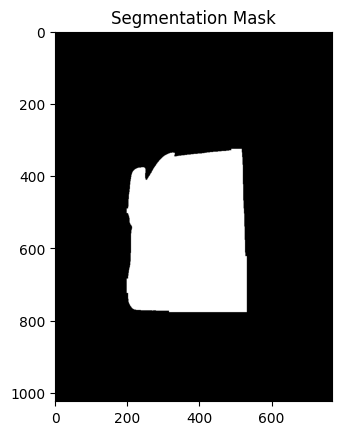

In [7]:
# Mask Visualization

import numpy as np
mask = results[0].masks.data[0].cpu().numpy() 
# extracts segmentation mask from YOLO output for first detected object (class 0: door) and converts into a numpy array for OpenCV usage
# results[0] = first image in prediction
# masks.data[0] = first detected object mask
# mask of first object detected in the first image

# Plot
import matplotlib.pyplot as plt
plt.imshow(mask, cmap='gray')
plt.title("Segmentation Mask")
plt.show()

In [10]:
import numpy as np

poly = results[0].masks.xy[0].astype(np.int32)
img = results[0].orig_img.copy()

# Draw yellow contour Lines on image copy
e = 0.0015 * cv2.arcLength(poly, True) # change e for smoother results. smaller number = more complexity
smooth = cv2.approxPolyDP(poly, e, True)
cv2.drawContours(img, [smooth], -1, (0,255,255), 2)
contour = smooth.reshape(-1, 2)

# Bottom Edge Band
bottom_y = np.percentile(contour[:,1], 99)
bottom_band = contour[contour[:,1] > bottom_y - 40]

# (1) Bottom Left Corner
bottom_left = bottom_band[np.argmin(bottom_band[:,0])]

# (2) Bottom Right Corner 
bottom_right = bottom_band[np.argmax(bottom_band[:,0])]

# (3) 50% Middle Bottom Edge Band
bottom_50 = np.array([
    int((bottom_left[0] + bottom_right[0]) / 2),
    int((bottom_left[1] + bottom_right[1]) / 2)
])

# (4) 25% along Bottom Edge Band (interpolated)
bottom_25 = np.array([
    int(bottom_left[0] + 0.25 * (bottom_right[0] - bottom_left[0])),
    int(bottom_left[1] + 0.25 * (bottom_right[1] - bottom_left[1]))
])

# (5) 75% along Bottom Edge Band (interpolated)
bottom_75 = np.array([
    int(bottom_left[0] + 0.75 * (bottom_right[0] - bottom_left[0])),
    int(bottom_left[1] + 0.75 * (bottom_right[1] - bottom_left[1]))
])

# (6) Top Right Corner
top_y = np.min(contour[:,1])
top_pts = contour[contour[:,1] < top_y + 20]
top_right = top_pts[np.argmax(top_pts[:,0])]

# (7) 50% Middle Right Edge Band
right_50 = np.array([
    int((bottom_right[0] + top_right[0]) / 2),
    int((bottom_right[1] + top_right[1]) / 2)
])

# (8) 25% along Right Edge Band (interpolated)
right_25 = np.array([
    int(bottom_right[0] + 0.25 * (top_right[0] - bottom_right[0])),
    int(bottom_right[1] + 0.25 * (top_right[1] - bottom_right[1]))
])

# (9) 75% along Right Edge Band (interpolated)
right_75 = np.array([
    int(bottom_right[0] + 0.75 * (top_right[0] - bottom_right[0])),
    int(bottom_right[1] + 0.75 * (top_right[1] - bottom_right[1]))
])

# Point Coordinate Array for #1-9
points = np.array([
    bottom_left, #1
    bottom_right, #2
    bottom_50, #3
    bottom_25, #4
    bottom_75, #5
    top_right, #6
    right_50, #7
    right_25, #8
    right_75, #9
], dtype=np.float32)

# Annotated Points on Image Copy
for pt in points:
    cv2.circle(img, tuple(pt.astype(int)), 6, (255,0,0), -1)

# Save Image as <file path>
cv2.imwrite("img729_contour3.jpg", img)

True

In [13]:
# Prints coordinate points

print(f"""
1) bottom_left:     {bottom_left}
2) bottom_right:    {bottom_right}
3) bottom_50:       {bottom_50}
4) bottom_25:       {bottom_25}
5) bottom_75:       {bottom_75}
6) top_right:       {top_right}
7) right_50:        {right_50}
8) right_25:        {right_25}
9) right_75:        {right_75}
""")

# (0,0) TOP LEFT


1) bottom_left:     [ 340 1215]
2) bottom_right:    [ 836 1229]
3) bottom_50:       [ 588 1222]
4) bottom_25:       [ 464 1218]
5) bottom_75:       [ 712 1225]
6) top_right:       [814 515]
7) right_50:        [825 872]
8) right_25:        [ 830 1050]
9) right_75:        [819 693]



In [14]:
# Centerline annotation

img_center = results[0].orig_img.copy()

# Draw contour again
cv2.drawContours(img_center, [smooth], -1, (0,255,255), 2)

# Draw existing points again
for pt in points:
    cv2.circle(img_center, tuple(pt.astype(int)), 6, (255,0,0), -1)

# Centerline direction (parallel to right door edge)
edge_dir = top_right - bottom_right

# Start and end of centerline
center_start = bottom_50
center_end = bottom_50 + edge_dir

# Draw centerline (red)
cv2.line(
    img_center,
    tuple(center_start.astype(int)),
    tuple(center_end.astype(int)),
    (0,0,255),
    3
)

#Save result
cv2.imwrite("centerline_annotation.jpg", img_center)

True